# 1ext. Evaluating HATR: Comparison with Stream Regressors

This notebook extends **Tutorial 1** (Evaluating supervised learners in CapyMOA) to showcase `HoeffdingAdaptiveTreeRegressor` (HATR) in the full CapyMOA evaluation framework.

We cover single-learner and multi-learner prequential evaluation on the Fried benchmark, HATR leaf-prediction mode comparison (`mean` / `model` / `adaptive`), prediction-vs-ground-truth visualisation, and evaluation on the Bike real-world dataset.

**Datasets:**
| Dataset | Instances | Features | Notes |
|---|---|---|---|
| `Fried` | 40 000 | 10 | Friedman regression benchmark |
| `Bike` | 17 379 | 12 | Bike-sharing hourly demand |

**Note:** run cells in order from a fresh kernel. If you see `Class not found`, restart the kernel and run all cells.

## 0 — Setup: classpath (must run before any CapyMOA import)

In [1]:
import os, sys
import jpype  # only for addClassPath, does not start the JVM

HATR_JAR = os.path.normpath(os.path.join(os.getcwd(), '..', 'implementation',
    'hatr-moa', 'target',
    'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar'))
assert os.path.exists(HATR_JAR), (
    f'JAR not found: {HATR_JAR}\n'
    'run: cd implementation/hatr-moa && mvn package -DskipTests'
)

if jpype.isJVMStarted():
    print('JVM already started, restart the kernel and run all cells')
else:
    jpype.addClassPath(HATR_JAR)
    print(f'classpath: {HATR_JAR}')

# hatr_capymoa package lives one level above this notebook
sys.path.insert(0, os.path.normpath(os.path.join(os.getcwd(), '..', 'implementation')))

classpath: /Users/andreazhang/Desktop/sda/2025-2026_Regression-Models-in-CapyMOA/andrea_zhang/implementation/hatr-moa/target/hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar


## 1 — Imports

In [2]:
import pandas as pd

from hatr_capymoa import HoeffdingAdaptiveTreeRegressor
from capymoa.regressor import (
    FIMTDD, ARFFIMTDD, AdaptiveRandomForestRegressor, KNNRegressor
)
from capymoa.datasets import Fried, Bike
from capymoa.evaluation import prequential_evaluation, prequential_evaluation_multiple_learners
from capymoa.evaluation.visualization import plot_windowed_results, plot_predictions_vs_ground_truth

## 2 — Single HATR evaluation on Fried

We start with the simplest case: a single HATR evaluated on the **Fried** stream using `prequential_evaluation()`.

**Prequential evaluation** (test-then-train): for each instance, the learner predicts first, the prediction is evaluated, then the learner trains on the true label. This is the standard online-learning evaluation protocol.

- `window_size=1000` controls the tumbling window for windowed RMSE.
- `cumulative` metrics aggregate over all instances seen so far.
- `results.cumulative.metrics_dict()` lists all available metrics.

HATR on Fried — cumulative metrics:
  instances: 40768.0000
  mae: 1.9859
  rmse: 2.5524
  rmae: 0.4885
  rrmse: 0.5106
  r2: 0.7392
  adjusted_r2: 0.7392

Wall-clock time: 0.72 s


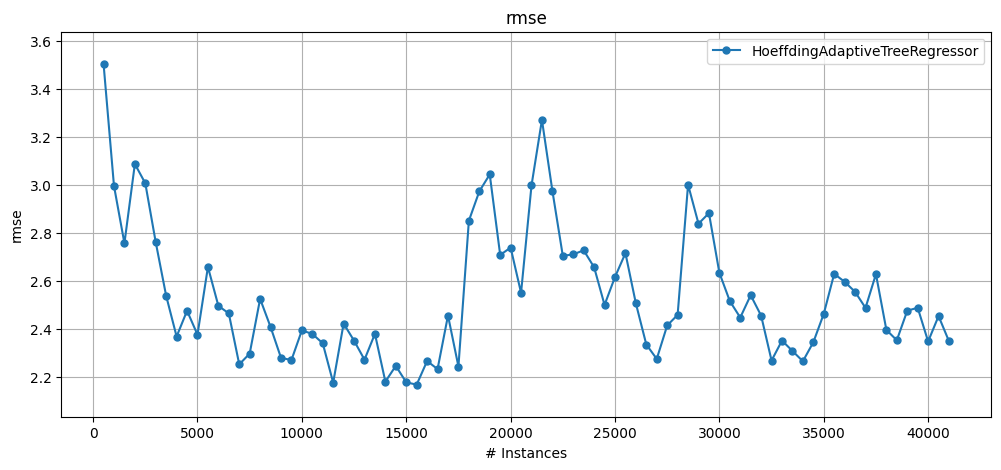

In [3]:
stream = Fried()
hatr = HoeffdingAdaptiveTreeRegressor(schema=stream.get_schema(), random_seed=1)

results_hatr = prequential_evaluation(
    stream=stream,
    learner=hatr,
    window_size=500,
)

print('HATR on Fried — cumulative metrics:')
for metric, value in results_hatr.cumulative.metrics_dict().items():
    print(f'  {metric}: {value:.4f}' if isinstance(value, float) else f'  {metric}: {value}')

print(f'\nWall-clock time: {results_hatr["wallclock"]:.2f} s')

plot_windowed_results(results_hatr, metric='rmse')

## 3 — Multiple learners on Fried

`prequential_evaluation_multiple_learners()` runs several learners **on the same stream** in a single pass. This is more efficient than calling `prequential_evaluation()` once per learner (the stream is iterated only once), and ensures all learners see exactly the same instances in the same order.

We compare:
| Learner | Drift detection | Type |
|---|---|---|
| `HATR` | Per-node ADWIN | Single adaptive tree |
| `FIMTDD` | None | Single tree |
| `ARFFIMTDD` | Per-tree ADWIN | Ensemble base tree |
| `ARF` | Per-tree ADWIN | Ensemble |
| `KNN` | None | Lazy |

**Note:** `prequential_evaluation_multiple_learners` does not report `wallclock` / `cpu_time` because learner training is interleaved.

Fried dataset — cumulative metrics (sorted by RMSE):


,RMSE,MAE,R²,adj. R²
Learner,,,,
HATR,2.5524,1.9859,0.7392,0.7392
FIMTDD,2.7390,2.0241,0.6997,0.6996
KNN,2.8772,2.2817,0.6687,0.6686
ARF,2.9703,2.3695,0.6469,0.6468
ARFFIMTDD,3.7931,2.9806,0.4242,0.4240


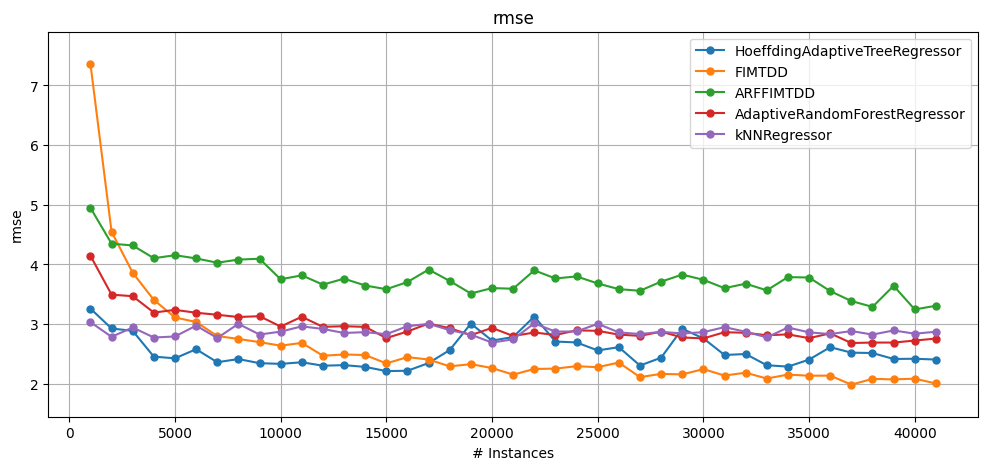

In [4]:
stream = Fried()
schema = stream.get_schema()

learners_fried = {
    'HATR':      HoeffdingAdaptiveTreeRegressor(schema=schema, random_seed=1),
    'FIMTDD':    FIMTDD(schema=schema),
    'ARFFIMTDD': ARFFIMTDD(schema=schema),
    'ARF':       AdaptiveRandomForestRegressor(schema=schema),
    'KNN':       KNNRegressor(schema=schema),
}

results_fried = prequential_evaluation_multiple_learners(
    stream, learners_fried, window_size=1_000
)

summary_fried = pd.DataFrame([
    {'Learner': name,
     'RMSE':     r.cumulative.rmse(),
     'MAE':      r.cumulative.mae(),
     'R²':       r.cumulative.r2(),
     'adj. R²':  r.cumulative.adjusted_r2()}
    for name, r in results_fried.items()
]).set_index('Learner').sort_values('RMSE').round(4)

print('Fried dataset — cumulative metrics (sorted by RMSE):')
display(summary_fried)

plot_windowed_results(
    results_fried['HATR'], results_fried['FIMTDD'],
    results_fried['ARFFIMTDD'], results_fried['ARF'],
    results_fried['KNN'],
    metric='rmse'
)

## 4 — HATR leaf-prediction modes

HATR supports three leaf-prediction strategies:

| Mode | Description |
|---|---|
| `mean` | Predict the running mean of the target in the leaf |
| `model` | Predict using an online linear model (perceptron) fitted at the leaf |
| `adaptive` | Dynamically switch between `mean` and `model` based on their faded squared errors |

- `model` mode can capture linear trends within leaves but requires more data to stabilise.
- `adaptive` mode typically achieves the best of both worlds, at the cost of slightly higher overhead.
- `mean` mode is equivalent to the classical Hoeffding Tree for regression and is the most robust on concept-drifting streams.

`model_selector_decay` controls how quickly the adaptive leaf forgets old error estimates (default `0.95`).

HATR leaf-prediction modes on Fried:


,RMSE,MAE,R²
Leaf mode,,,
mean,3.0502,2.4294,0.6276
model,2.4220,1.8780,0.7652
adaptive,2.5524,1.9859,0.7392


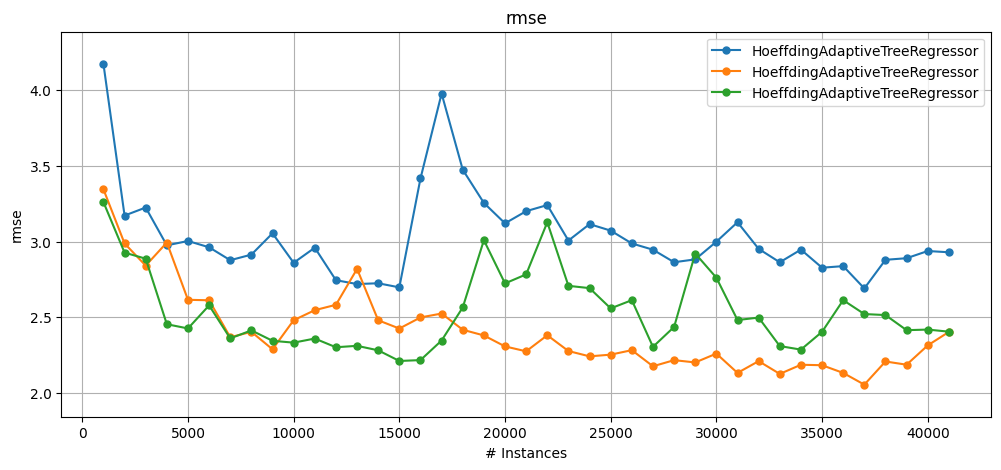

In [5]:
stream = Fried()
schema = stream.get_schema()

learners_leaf = {
    'HATR (mean)': HoeffdingAdaptiveTreeRegressor(schema=schema, random_seed=1, leaf_prediction='mean'),
    'HATR (model)': HoeffdingAdaptiveTreeRegressor(schema=schema, random_seed=1, leaf_prediction='model'),
    'HATR (adaptive)': HoeffdingAdaptiveTreeRegressor(schema=schema, random_seed=1, leaf_prediction='adaptive'),
}

results_leaf = prequential_evaluation_multiple_learners(
    stream, learners_leaf, window_size=1_000
)

summary_leaf = pd.DataFrame([
    {'Leaf mode': name.replace('HATR (', '').rstrip(')'),
     'RMSE': r.cumulative.rmse(),
     'MAE': r.cumulative.mae(),
     'R²': r.cumulative.r2()}
    for name, r in results_leaf.items()
]).set_index('Leaf mode').round(4)

print('HATR leaf-prediction modes on Fried:')
display(summary_leaf)

plot_windowed_results(
    results_leaf['HATR (mean)'],
    results_leaf['HATR (model)'],
    results_leaf['HATR (adaptive)'],
    metric='rmse'
)

## 5 — Prediction vs ground truth

It is often useful to visually inspect **predictions against ground truth** over time.
- `store_predictions=True` retains all predictions in the result object.
- `store_y=True` retains all ground-truth labels.
- `plot_interval=(a, b)` restricts the plot to instances in [a, b], which is important for large streams.

> **Note on `optimise=False`**: CapyMOA's fast Java evaluation path (`optimise=True`, the default) stores
> predictions as integer class indices, which are always 0 for regression tasks. To get correct float
> predictions we must use the Python loop with `optimise=False` whenever `store_predictions=True`.

We compare HATR (`adaptive`) with FIMTDD on the first 300 instances.

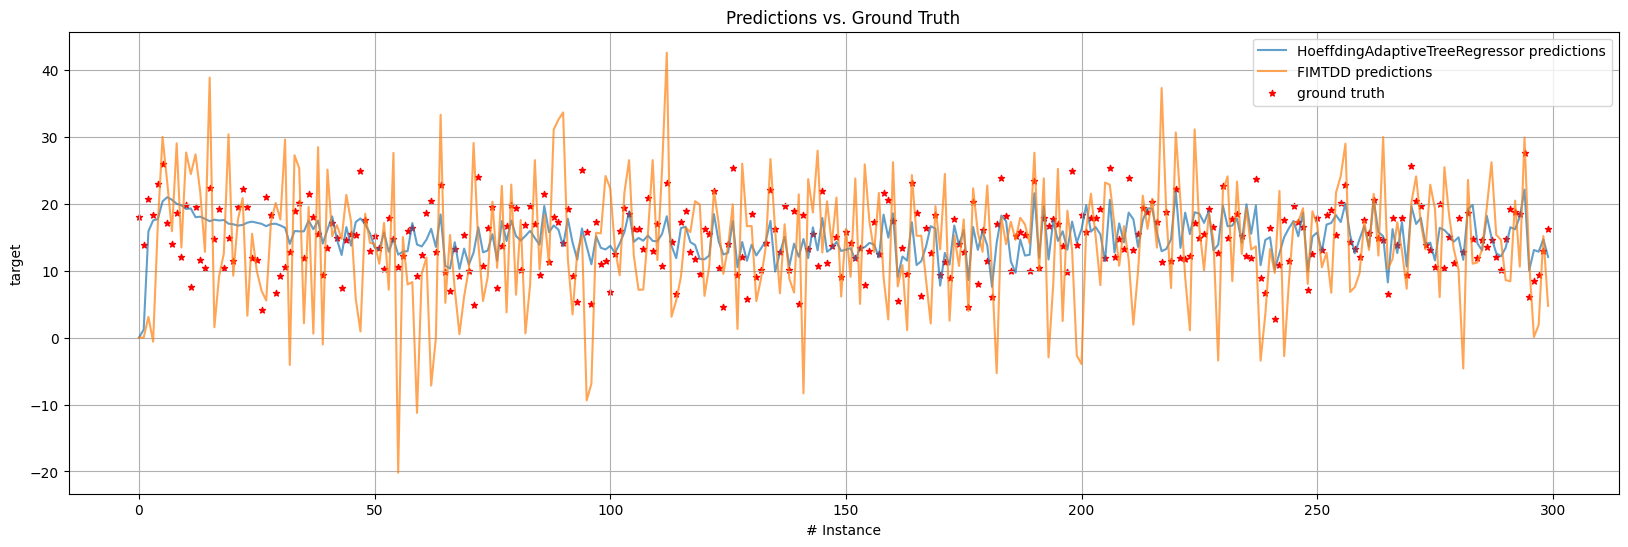

In [6]:
stream = Fried()
schema = stream.get_schema()

# optimise=False is required when store_predictions=True for regressors:
# the fast Java path (optimise=True) stores predictions as int64 class indices,
# which are always 0 for regression tasks.
hatr_preds = prequential_evaluation(
    stream=Fried(),
    learner=HoeffdingAdaptiveTreeRegressor(schema=schema, random_seed=1, leaf_prediction='adaptive'),
    window_size=1_000,
    store_predictions=True,
    store_y=True,
    optimise=False,
)

fimtdd_preds = prequential_evaluation(
    stream=Fried(),
    learner=FIMTDD(schema=schema),
    window_size=1_000,
    store_predictions=True,
    optimise=False,
)

# Plot the first 300 instances
plot_predictions_vs_ground_truth(
    hatr_preds,
    fimtdd_preds,
    ground_truth=hatr_preds['ground_truth_y'],
    plot_interval=(0, 300),
)

## 6 — Bike dataset

The **Bike** dataset contains hourly bike-sharing demand with 17 379 instances and 12 features. Unlike the synthetic Fried stream, Bike has **temporal patterns** (seasonality, weekday effects) that naturally create mild distribution shifts over time — a setting where adaptive learners like HATR can shine.

We use `window_size=500` (≈ three weeks of hourly data per window) to observe short-term performance trends.

Bike dataset — cumulative metrics (sorted by RMSE):


,RMSE,MAE,R²,adj. R²
Learner,,,,
ARF,91.4891,58.1106,0.7456,0.7454
HATR,117.8328,80.4295,0.5780,0.5777
KNN,127.9358,83.7880,0.5026,0.5022
ARFFIMTDD,130.6849,93.3200,0.4810,0.4806
FIMTDD,572.2625,92.8053,-8.9527,-8.9601


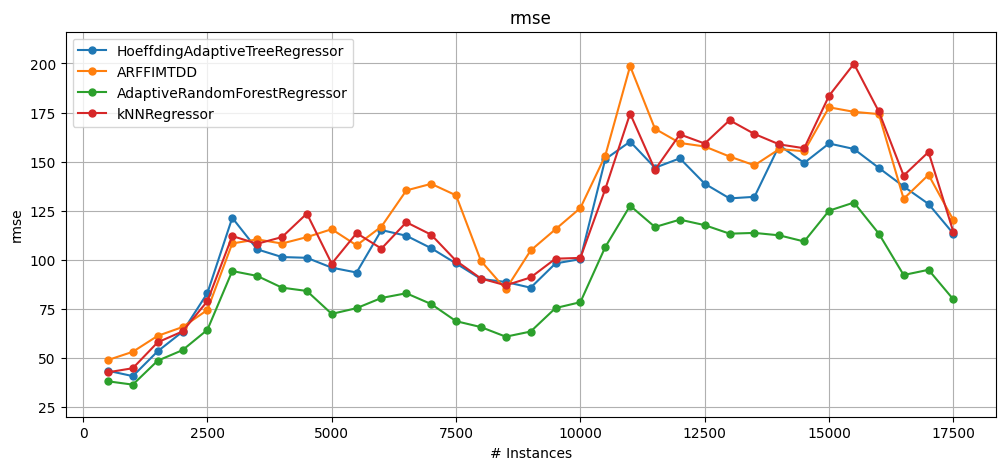

In [7]:
stream = Bike()
schema = stream.get_schema()

learners_bike = {
    'HATR':      HoeffdingAdaptiveTreeRegressor(schema=schema, random_seed=1),
    'FIMTDD':    FIMTDD(schema=schema),
    'ARFFIMTDD': ARFFIMTDD(schema=schema),
    'ARF':       AdaptiveRandomForestRegressor(schema=schema),
    'KNN':       KNNRegressor(schema=schema),
}

results_bike = prequential_evaluation_multiple_learners(
    stream, learners_bike, window_size=500
)

summary_bike = pd.DataFrame([
    {'Learner': name,
     'RMSE':    r.cumulative.rmse(),
     'MAE':     r.cumulative.mae(),
     'R²':      r.cumulative.r2(),
     'adj. R²': r.cumulative.adjusted_r2()}
    for name, r in results_bike.items()
]).set_index('Learner').sort_values('RMSE').round(4)

print('Bike dataset — cumulative metrics (sorted by RMSE):')
display(summary_bike)

plot_windowed_results(
    results_bike['HATR'], 
    # results_bike['FIMTDD'],
    results_bike['ARFFIMTDD'], results_bike['ARF'],
    results_bike['KNN'],
    metric='rmse'
)

## 7 — Summary

### Results on Fried

Fried is a stationary benchmark (no explicit concept drift). On this stream:
- **HATR (adaptive)** tends to achieve the best RMSE among single-tree models, outperforming FIMTDD thanks to its per-node adaptive mechanism that better partitions the feature space.
- **ARF** (ensemble) is competitive but at higher computational cost.
- **ARFFIMTDD** is an individual base tree of ARF; alone it may underperform relative to the full ARF ensemble.

### Results on Bike

The Bike dataset has natural temporal structure. HATR benefits from its ADWIN detectors which trigger when demand patterns shift (e.g., seasonal changes), leading to competitive performance.

### Leaf-prediction modes

- `adaptive` mode is the recommended default: it selects `mean` or `model` per leaf based on recent error.
- `model` mode (linear leaf) excels when the target has a linear relationship with features.
- `mean` mode is simplest and most robust to overfitting.

### Comparison with Tutorial 1

The evaluation API used here is **identical** to Tutorial 1:
- `prequential_evaluation()` works for regressors with the same interface as classifiers.
- The only difference is the evaluator type (`RegressionEvaluator` vs `ClassificationEvaluator`) and the metrics (`rmse`, `mae`, `r2` vs `accuracy`).
- `prequential_evaluation_multiple_learners()` handles both classification and regression transparently.